# Locating resolution-dependent behavioral correspondence in qualitative DNA-damage response models
### Journal: accepted Journal of Bioinformatics and Computational Biology paper

This is the canonical executed notebook for [the accepted main paper](../Journal/main.tex)
and [its supplement](../Journal/supplement.tex). It contains the death-receptor
comparison, GIM observational-interface analysis, curated model controls,
independent formal verification, PN-GDDA comparisons, and exploratory
HPN-DREAM/CASPOTS analysis reported in those sources.

The death-receptor comparison separates endpoint agreement, conditioned exact
trace equality, and intervention-dependent futures. Global sustained trace
equality is refuted by a verified 12-action word; reverse inclusion remains
undecided. No new experimental validation or uniquely observed hidden state is
claimed. The feedback/withdrawal phenomenon was reported by Calzone et al.
(2010); this analysis reconstructs its relational and reachable-future
interpretation. All biological conclusions are conditional on the encoded
models, fixed interfaces, initial conditions, and update semantics.

#### Execution and stored evidence

The embedded outputs can be inspected without executing the notebook. They
retain the recorded calculations and execution counts; renaming files and
variables does not constitute a new execution. Counts can contain gaps where
out-of-scope exploratory cells were removed. Historical timings, resource-cap
progress, and dependency warnings describe the recorded run. Machine-specific
paths in stored text have been replaced by portable placeholders; numerical
results and images are unchanged.

For regeneration, use Python 3.11 with `python -m pip install -r requirements.txt`
from the repository root. Graphviz (`dot`) and mCRL2 (`ltscompare`, recorded
version 202607.0) are system dependencies; set `MCRL2_LTSCOMPARE` when needed.
Fetch/verify the public inputs with `python scripts/fetch_public_models.py` and
`python scripts/fetch_hpn_dream.py`. Death-receptor source verification runs in
its analysis cell. Start the kernel from the repository root or `notebooks/`
and run the retained cells in order.

The death-receptor cell regenerates million-state graphs and may need several
GiB of memory. The formal cells also run exhaustive finite checks and external
tools. A complete execution is therefore not a quick preview. From the root,
execute with `python -m jupyter nbconvert --to notebook --execute --inplace
--ExecutePreprocessor.timeout=-1 notebooks/metodologia_multiescala.ipynb`.

The PN-GDDA and HPN cells load the committed independent-validation records
`results/holmes_pn_gdda_external_validation.json`,
`results/hpn_dream_caspots_rmse.csv`, and
`results/hpn_dream_caspots_summary.json`. These records are not recalculated by
those cells. To rebuild them, run `python scripts/validate_holmes_pn_gdda.py`
(Java compiler/runtime required), or create the Conda environment from
`environment-hpn.yml`
and run `conda run -n bisimulationmol-hpn python
scripts/run_caspots_hpn_validation.py --repeats 2`, respectively.


In [1]:
# Setup and engine import
from pathlib import Path
import sys, os

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
PROJECT_ROOT = next(
    (p for p in candidates if (p / "src" / "concurrent_biomodels.py").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks/ directory.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydot
from IPython.display import Image, display

import concurrent_biomodels as cbm
import method_benchmark as mb
import pn_gdda as png
import public_validation as pv
import hpn_dream_validation as hpn
import gim_interface_analysis as gim
import simulation_oracle as sim_oracle

pd.set_option("display.max_colwidth", 70)
print("Project root:", PROJECT_ROOT)
print("Available modules:", list(cbm.MODULES))


def show_petri(net, title=""):
    "Draw a Petri net with Graphviz (circle = place, box = transition)."
    g = pydot.Dot(graph_type="digraph", rankdir="LR", splines="spline",
                  nodesep="0.3", ranksep="0.6", label=title, labelloc="t",
                  fontsize="15")
    g.set_dpi("110")
    bullet = "\u25cf"
    for p in net.places:
        tok = net.init.get(p, 0)
        lbl = p if not tok else f"{p}\n{bullet*tok}"
        g.add_node(pydot.Node(f"p_{p}", shape="circle", style="filled",
                              fillcolor="#eaf1fb", color="#3b6fb5",
                              penwidth="1.6", fontsize="10", label=lbl))
    for t in net.transitions:
        tau = t.label == cbm.TAU
        sym = "\u03c4" if tau else t.label
        g.add_node(pydot.Node(f"t_{t.name}", shape="box", style="filled,rounded",
                              fillcolor="#f0f0f0" if tau else "#fff3d6",
                              color="#9a9a9a" if tau else "#c9962b",
                              penwidth="1.6", fontsize="9",
                              label=f"{t.name}\n[{sym}]"))
        for p in t.pre:
            g.add_edge(pydot.Edge(f"p_{p}", f"t_{t.name}", color="#666"))
        for p in t.post:
            g.add_edge(pydot.Edge(f"t_{t.name}", f"p_{p}", color="#666"))
    display(Image(g.create_png()))


def show_lts(lts, title=""):
    "Draw the reachability graph (LTS); τ dashed, observable solid."
    g = pydot.Dot(graph_type="digraph", rankdir="TB", label=title, labelloc="t",
                  fontsize="15")
    g.set_dpi("110")
    for i in range(len(lts.states)):
        g.add_node(pydot.Node(str(i), shape="circle", style="filled",
                              fillcolor="#d6ecd8" if i == lts.init else "#eef4fb",
                              color="#3b6fb5", fontsize="10"))
    for s, a, d in lts.edges:
        if a == cbm.TAU:
            g.add_edge(pydot.Edge(str(s), str(d), label="\u03c4", color="#9a9a9a",
                                  style="dashed", fontsize="9"))
        else:
            g.add_edge(pydot.Edge(str(s), str(d), label=a, color="#8a5a00",
                                  fontsize="9"))
    display(Image(g.create_png()))


<python site-packages>/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Project root: <repository root>
Available modules: ['GIM', 'DCE', 'SPS', 'RCD', 'AID']


## Fixed-interface death-receptor commitment

The original Calzone model and its documented feedback-deletion variant share
stable-fate predictions under sustained TNF. A selected shared-state continuation
has exact baseline agreement but different withdrawal futures. Global sustained
trace equality is refuted by a verified 12-action word; reverse inclusion is
still undecided. With withdrawal, global traces also differ: this is not a
globally equal-trace/different-branching biological example.

The next cell regenerates the large graphs, counterexamples, and Journal Figure 1.
It needs several GiB of memory, Numba/SciPy, and mCRL2; raw AUT export is optional.
The following cell verifies the selected full-model continuation. GIM, curated
controls, HPN, PN-GDDA, and formal checks provide the supporting evidence.

The stored sustained-search status `inconclusive` applies to completion of the
subset-product search and the reverse inclusion. The finite counterexample
already refutes equality; a resource limit is not itself evidence of inequality.


Verified source and frozen configuration: 408936bf397586897e72b73004084c7210a81084b9b74826ce7d7e6d637075c6


DR-FB+ sustained 1044457 10296917 ['apoptosis', 'necrosis', 'survival']


DR-FB+ withdrawal 3133393 32980090 ['apoptosis', 'naive', 'necrosis']


DR-FB- sustained 547021 5062632 ['apoptosis', 'necrosis', 'survival']


DR-FB- withdrawal 2140569 21544296 ['naive', 'necrosis']


...

{'amendments': ['branching_case_amendment_01.json',
  'branching_case_amendment_02.json',
  'branching_case_amendment_03.json'],
 'common_observable_prefix': ['CASP3_up'],
 'common_raw_depth': 8,
 'configuration_sha256': '408936bf397586897e72b73004084c7210a81084b9b74826ce7d7e6d637075c6',
 'models': {'DR-FB+': {'sustained': {'edges': 10296917,
    'graph_sha256': '717121f42db42e39fd94832f200a2bcc31977156bb3c17f279d9476edf17ce19',
    'initial_reachable_terminal_fates': ['apoptosis', 'necrosis', 'survival'],
    'states': 1044457,
    'terminal_components': [{'fate': 'necrosis', 'size': 1, 'states': [4380]},
     {'fate': 'apoptosis', 'size': 1, 'states': [400]},
     {'fate': 'survival', 'size': 1, 'states': [275]}]},
   'withdrawal': {'edges': 32980090,
    'graph_sha256': 'cd2f973cffa0188484e712c7d0543e8b7445aeb44b47f68b5cf0f2161721fbf9',
    'initial_reachable_terminal_fates': ['apoptosis', 'naive', 'necrosis'],
    'states': 3133393,
    'terminal_components': [{'fate': 'naive', 'si

{'certificate': None,
 'classification': 'equivalent',
 'exact_trace_equal': True,
 'external_mcrl2': {'mcrl2_strong_bisimilar': True,
  'mcrl2_weak_bisimilar': True,
  'mcrl2_weak_trace_equivalent': True},
 'graphs': [{'edges': 2, 'states': 3}, {'edges': 2, 'states': 3}],
 'left_simulated_by_right': True,
 'right_simulated_by_left': True,
 'strong_bisimilar': True,
 'traces': {'algorithm': 'epsilon-NFA subset-product BFS, all states accepting',
  'exact_trace_equal': True,
  'left_only_trace': None,
  'left_trace_included_in_right': True,
  'max_subsets': 10000,
  'right_only_trace': None,
  'right_trace_included_in_left': True,
  'status': 'complete',
  'subset_product_states': 1},
 'weak_bisimilar': True}

{'DR-FB+': {'compatible_states_before_withdrawal': 78,
  'reachable_terminal_fates_after_withdrawal': ['apoptosis',
   'naive',
   'necrosis']},
 'DR-FB-': {'compatible_states_before_withdrawal': 78,
  'reachable_terminal_fates_after_withdrawal': ['naive', 'necrosis']}}

,prefix_or_step,model,TNF_status,reachable_states_before_withdrawal,reachable_naive,reachable_survival,reachable_apoptosis,reachable_necrosis,states_with_unique_terminal_apoptosis,states_with_persistent_CASP3,committed_fate_if_any,observable_state
0,0,DR-FB+,0,1,1,0,0,0,0,0,state-specific; not a population probability,aggregate of all states at exactly this raw-event depth
1,1,DR-FB+,0,1,1,0,1,1,0,0,state-specific; not a population probability,aggregate of all states at exactly this raw-event depth
2,2,DR-FB+,0,2,1,0,1,1,0,0,state-specific; not a population probability,aggregate of all states at exactly this raw-event depth
3,3,DR-FB+,0,4,1,0,1,1,0,0,state-specific; not a population probability,aggregate of all states at exactly this raw-event depth
4,4,DR-FB+,0,7,1,0,1,1,0,0,state-specific; not a population probability,aggregate of all states at exactly this raw-event depth
5,5,DR-FB+,0,12,1,0,1,1,0,0,state-specific; not a population probability,aggregate of all states at exactly this raw-event depth
6,6,DR-FB+,0,23,1,0,1,1,0,0,state-specific; not a population probability,aggregate of all states at exactly this raw-event depth
7,7,DR-FB+,0,42,1,0,1,1,0,0,state-specific; not a population probability,aggregate of all states at exactly this raw-event depth
8,8,DR-FB+,0,73,1,0,1,1,1,1,state-specific; not a population probability,aggregate of all states at exactly this raw-event depth
9,9,DR-FB+,0,122,1,0,1,1,1,1,state-specific; not a population probability,aggregate of all states at exactly this raw-event depth


{'checks': [{'accepted': True,
   'model': 'DR-FB+',
   'status': 'witness found',
   'trace': ['withdraw_TNF', 'CASP3_up', 'CASP3_down', 'CASP3_up'],
   'visited_product_states': 5356},
  {'accepted': False,
   'model': 'DR-FB-',
   'status': 'exhausted exact product',
   'trace': ['withdraw_TNF', 'CASP3_up', 'CASP3_down', 'CASP3_up'],
   'visited_product_states': 3747},
  {'accepted': False,
   'model': 'DR-FB+',
   'status': 'exhausted exact product',
   'trace': ['CASP3_up', 'withdraw_TNF', 'CASP3_down'],
   'visited_product_states': 929},
  {'accepted': True,
   'model': 'DR-FB-',
   'status': 'witness found',
   'trace': ['CASP3_up', 'withdraw_TNF', 'CASP3_down'],
   'visited_product_states': 1124}],
 'configuration_sha256': '408936bf397586897e72b73004084c7210a81084b9b74826ce7d7e6d637075c6',
 'method': 'independent full 28-node tuple/product search using original rules, without compact execution or sink reduction',
 'scope': 'original full 28-node models; no sink reduction'}

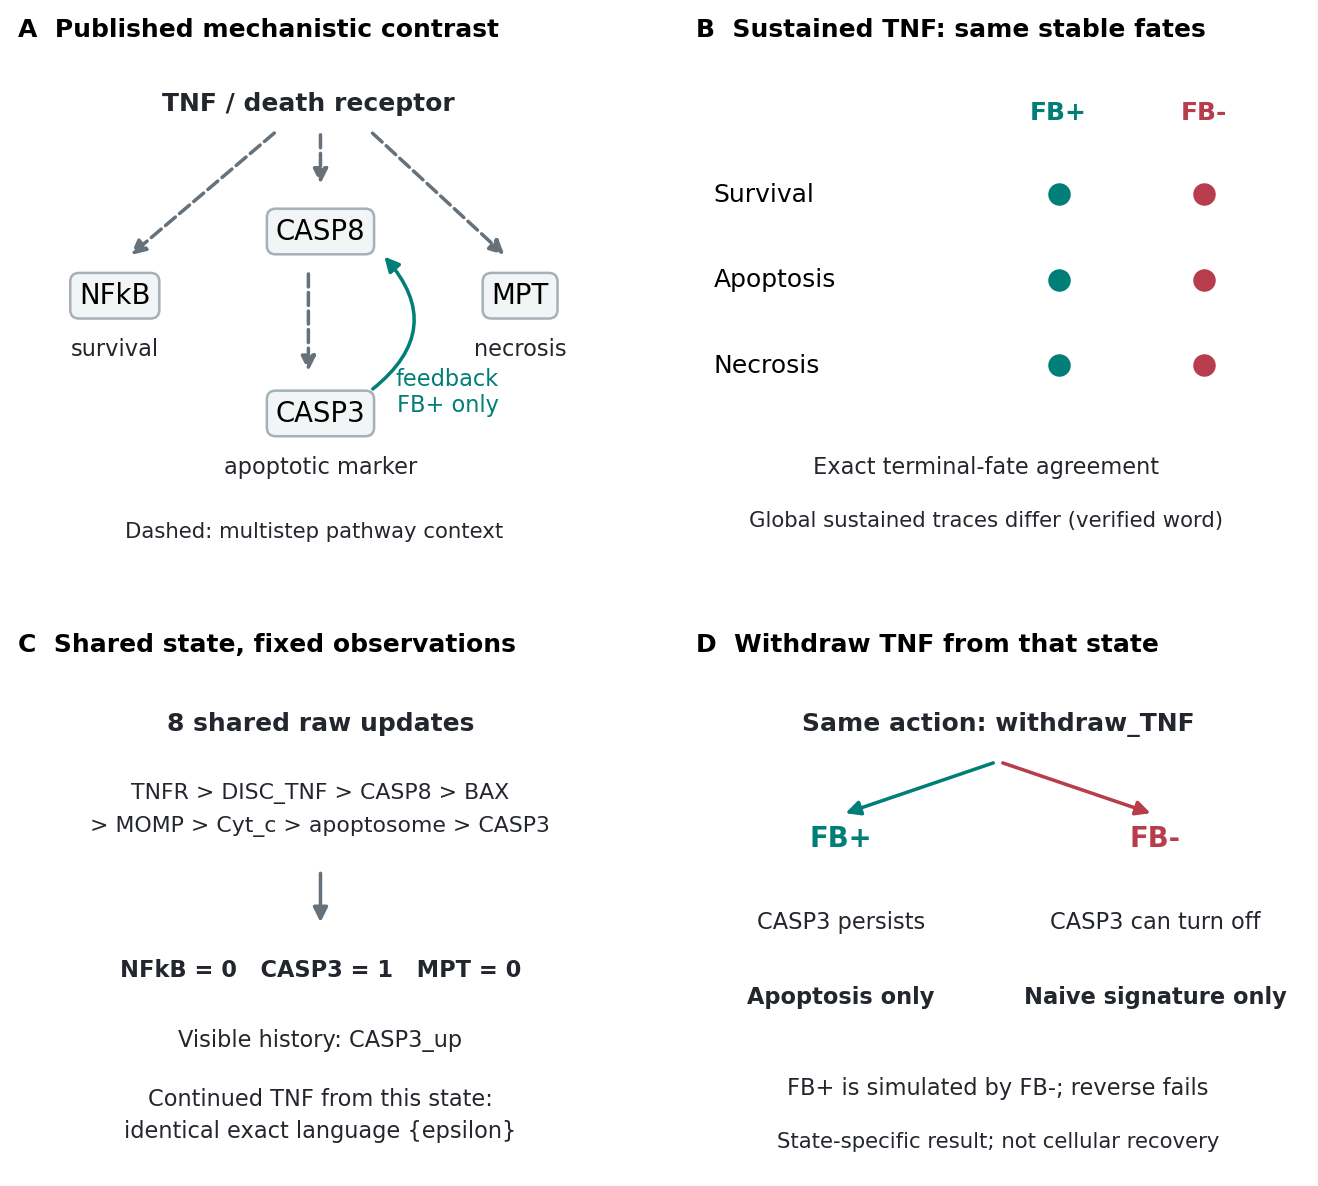

In [2]:
import subprocess
import json
sys.path.insert(0, str(PROJECT_ROOT))
subprocess.run([sys.executable, 'scripts/fetch_branching_models.py'], cwd=PROJECT_ROOT, check=True)
subprocess.run([sys.executable, 'scripts/run_branching_cases.py'], cwd=PROJECT_ROOT, check=True)
subprocess.run([sys.executable, 'scripts/run_death_receptor_external_audit.py', '--sustained-word-only'], cwd=PROJECT_ROOT, check=True)
death_receptor_baseline = json.loads((PROJECT_ROOT / 'results/death_receptor_sustained_comparison.json').read_text())
death_receptor_external_word = json.loads((PROJECT_ROOT / 'results/death_receptor_sustained_external_word.json').read_text())
assert death_receptor_baseline['trace_analysis']['exact_trace_equal'] is False
assert death_receptor_baseline['weak_simulations']['left_simulated_by_right'] is False
assert death_receptor_baseline['weak_simulations']['right_simulated_by_left'] is None
assert death_receptor_external_word['confirmed']
display(death_receptor_baseline['trace_analysis'])
display(death_receptor_external_word)
death_receptor_summary = json.loads((PROJECT_ROOT / 'results/death_receptor_execution_summary.json').read_text())
death_receptor_witness = json.loads((PROJECT_ROOT / 'results/death_receptor_branching_witness.json').read_text())
display({key: value for key, value in death_receptor_summary.items()
         if key != 'candidate_2_status'})
display(death_receptor_witness['conditioned_sustained'])
display(death_receptor_witness['history_aggregated_futures'])
display(pd.read_csv(PROJECT_ROOT / 'results/death_receptor_commitment_scan.csv').head(12))
display(json.loads((PROJECT_ROOT / 'results/death_receptor_independent_trace_audit.json').read_text()))
subprocess.run([sys.executable, 'scripts/make_death_receptor_figure.py'], cwd=PROJECT_ROOT, check=True)
from IPython.display import Image
display(Image(filename=str(PROJECT_ROOT / 'Journal/Fig1.png')))

In [3]:
from dataclasses import replace
from src.death_receptor_analysis import load_variants, OBSERVABLES
from src.controlled_interventions import generate
from src.branching_witness import find_branching_witness, verify_branching_witness
death_receptor_models = load_variants()
shared = tuple(death_receptor_witness['shared_retained_state'].get(v, 0) for v in death_receptor_models[0].variables)
full_continuations = [generate(replace(m, initial=shared), OBSERVABLES, withdraw='TNF') for m in death_receptor_models]
checked = find_branching_witness(full_continuations[0].lts, full_continuations[1].lts)
assert verify_branching_witness(full_continuations[0].lts, full_continuations[1].lts, checked)
assert checked['left_simulated_by_right'] and not checked['right_simulated_by_left']
assert not checked['weak_bisimilar'] and not checked['exact_trace_equal']
display({k:v for k,v in checked.items() if k != 'certificate'})

{'traces': {'status': 'complete',
  'algorithm': 'epsilon-NFA subset-product BFS, all states accepting',
  'exact_trace_equal': False,
  'left_trace_included_in_right': True,
  'right_trace_included_in_left': False,
  'left_only_trace': None,
  'right_only_trace': ['withdraw_TNF', 'CASP3_down'],
  'subset_product_states': 4,
  'max_subsets': 10000},
 'exact_trace_equal': False,
 'left_simulated_by_right': True,
 'right_simulated_by_left': False,
 'weak_bisimilar': False,
 'strong_bisimilar': False,
 'classification': 'trace_mismatch',
 'failed_relation': 'right_simulated_by_left'}

### GIM as a biological observational-interface experiment

The animal/human and Arabidopsis Petri-net structures are held fixed. Three
literature-motivated interfaces are declared before interpreting the formal
outcomes: A observes shared functions, B separates damage, signalling and
repair channels, and C additionally distinguishes apoptosis from the encoded
plant SMR and terminal response. Thus any change below is caused by
observational resolution rather than topology.

In [4]:
gim_output_paths = gim.write_outputs()
gim_interfaces = pd.DataFrame(gim.analysis_rows(k=6))
display(gim_interfaces[[
    "interface_id", "interface_name", "observable_labels",
    "animal_model_states", "plant_model_states",
    "animal_simulated_by_plant", "plant_simulated_by_animal",
    "formal_class", "trace_distance_k6", "pn_gdda_592_similarity"
]])

assert list(gim_interfaces["formal_class"]) == [
    "weak_bisimulation", "weak_bisimulation", "not_comparable"
]
assert np.allclose(gim_interfaces["trace_distance_k6"], [0.0, 0.0, 6 / 17])
assert gim_interfaces["pn_gdda_592_similarity"].nunique() == 1
assert not gim_interfaces["structure_changed_between_interfaces"].any()
assert all(path.exists() for path in gim_output_paths)
print("OK: unchanged structure, interface-dependent GIM behavioural result.")

,interface_id,interface_name,observable_labels,animal_model_states,plant_model_states,animal_simulated_by_plant,plant_simulated_by_animal,formal_class,trace_distance_k6,pn_gdda_592_similarity
0,A,coarse functional/process,cell_cycle_exit;checkpoint_activation;damage_detection;repair;rest...,13,14,True,True,weak_bisimulation,0.000000,0.997585
1,B,intermediate pathway,atm_pathway_signal;atr_pathway_signal;cell_cycle_exit;checkpoint_a...,13,14,True,True,weak_bisimulation,0.000000,0.997585
2,C,mechanism-resolved terminal fate,apoptosis;atm_pathway_signal;atr_pathway_signal;checkpoint_activat...,13,14,False,False,not_comparable,0.352941,0.997585


OK: unchanged structure, interface-dependent GIM behavioural result.


## Independent formal/software verification

The suite below is generated without using any biological case-study model.
Each pair is constructed to instantiate a known relation, so the expected result
is fixed before the algorithms are run. The binary task asks whether a pair is
strongly or weakly equivalent; one-way simulations remain visible as separate,
direction-preserving outcomes. This is not biological validation.

In [5]:
benchmark = pd.DataFrame(mb.validation_benchmark(n_steps=12, seed=17, k=8))
display(benchmark[[
    "case", "expected_class", "formal_class", "trace_distance",
    "pn_gdda_592_similarity", "pn_gdda_576_similarity",
    "lts_gda_similarity", "structural_similarity", "formal_match"
]])
assert benchmark["formal_match"].all()
print("OK: all six construction-level relations were recovered.")

,case,expected_class,formal_class,trace_distance,pn_gdda_592_similarity,pn_gdda_576_similarity,lts_gda_similarity,structural_similarity,formal_match
0,identity,strong equivalence,strong equivalence,0.0,1.000000,1.000000,1.000000,1.000000,True
1,silent refinement,weak equivalence,weak equivalence,0.0,1.000000,1.000000,0.798121,0.806250,True
2,label mismatch,not comparable,not comparable,0.8,1.000000,1.000000,0.718750,0.900000,True
3,label order swap,not comparable,not comparable,0.5,1.000000,1.000000,0.884615,1.000000,True
4,added branch,reference simulated by candidate,reference simulated by candidate,0.1,0.967638,0.966739,0.914359,0.893681,True
5,trace-equivalent branching,candidate simulated by reference,candidate simulated by reference,0.0,0.965731,0.964779,0.527845,0.775000,True


OK: all six construction-level relations were recovered.


### Comparison with non-formal baselines

PN-GDDA is evaluated directly using all 151 connected directed bipartite
graphlets through five nodes and the 592 orbit slots implemented by Holmes. Each
synthetic LTS is encoded canonically as a state-machine Petri net. LTS-GDA is a
separate label-aware reachable-state baseline combining four graphlet orbits
with directed labelled motifs. The simpler structural profile averages state
count, edge count, label multiset and out-degree multiset. The trace baseline
compares observable languages through depth eight. These methods test
complementary local, linear-time and branching-time views.

In [6]:
baseline = pd.DataFrame(mb.baseline_accuracy(benchmark.to_dict("records")))
pn_thresholds = pd.DataFrame(
    mb.pn_gdda_threshold_sensitivity(benchmark.to_dict("records"))
)
display(baseline)
display(pn_thresholds)
assert float(baseline.loc[baseline["method"] == "weak bisimulation", "accuracy"].iloc[0]) == 1.0
assert benchmark.loc[
    benchmark["case"] == "trace-equivalent branching", "trace_equivalent_at_k"
].iloc[0]
assert benchmark.loc[
    benchmark["case"] == "label order swap", "structurally_equivalent_at_0_9"
].iloc[0]
assert float(baseline.loc[baseline["method"] == "LTS-GDA (>=0.9)", "accuracy"].iloc[0]) == 4 / 6
assert float(baseline.loc[baseline["method"] == "PN-GDDA-592 (>=0.9)", "accuracy"].iloc[0]) == 2 / 6
assert float(pn_thresholds["accuracy"].max()) == 4 / 6
print("OK: the benchmark exposes the predeclared trace-only and structure-only failure cases.")

,method,accuracy,true_positive,true_negative,false_positive,false_negative,n_cases
0,weak bisimulation,1.000000,2,4,0,0,6
1,trace equality (k=8),0.833333,2,3,1,0,6
2,PN-GDDA-592 (>=0.9),0.333333,2,0,4,0,6
3,LTS-GDA (>=0.9),0.666667,1,3,1,1,6
4,structural profile (>=0.9),0.500000,1,2,2,1,6


,threshold,is_predeclared_0_9,accuracy,true_positive,true_negative,false_positive,false_negative
0,0.000000,False,0.333333,2,0,4,0
1,0.900000,True,0.333333,2,0,4,0
2,0.965731,False,0.333333,2,0,4,0
3,0.965731,False,0.500000,2,1,3,0
4,0.967638,False,0.500000,2,1,3,0
5,0.967638,False,0.666667,2,2,2,0
6,1.000000,False,0.666667,2,2,2,0


OK: the benchmark exposes the predeclared trace-only and structure-only failure cases.


### Direct PN-GDDA catalog and native-net audit

The published/Holmes 592-slot catalog is the primary comparator. A separate
type- and direction-preserving automorphism reconstruction yields 576 distinct
orbits and is retained as a sensitivity analysis. The four-node reference pair
below was also run independently in Holmes 1.1.1; `make holmes-pn-gdda` verifies
all 151 topology signatures and 592 root assignments from the official JAR.
The machine-readable record contains the JAR hash and both numerical scores. The five curated pairs are
then compared in their original Petri-net form rather than through reachable
LTS summaries.

In [7]:
import json

pn_catalog = png.catalog_validation()
pn_native = pd.DataFrame(png.native_module_comparisons(k=6))
with open(PROJECT_ROOT / "results" / "holmes_pn_gdda_external_validation.json") as handle:
    holmes_external = json.load(handle)
display(pd.DataFrame(pn_catalog["published_holmes_catalog"]))
display(pd.DataFrame(pn_catalog["automorphism_partition_sensitivity"]))
display(pn_native[[
    "module", "pn_gdda_592_similarity", "pn_gdda_576_similarity",
    "pn_gdda_equivalent_at_0_9", "formal_class"
]])
print("Holmes reference:", pn_catalog["holmes_reference_score"])
print("Independent score:", pn_catalog["independent_python_score"])
print("External catalog audit:", holmes_external)

assert pn_catalog["published_graphlet_total"] == 151
assert pn_catalog["published_orbit_slot_total"] == 592
assert pn_catalog["automorphism_orbit_total"] == 576
assert pn_catalog["score_agreement_at_12_decimals"]
assert holmes_external["catalog_matches_python"]
assert holmes_external["holmes_graphlet_topologies"] == 151
assert holmes_external["holmes_catalog_slots_verified"] == 592
assert pn_native["pn_gdda_equivalent_at_0_9"].all()
assert (pn_native["catalog_sensitivity_delta"].abs() < 0.001).all()
print("OK: direct PN-GDDA is reproduced, externally checked and sensitivity-audited.")

,size,graphlets,orbits
0,2,2,4
1,3,6,14
2,4,23,72
3,5,120,502


,size,graphlets,orbits
0,2,2,4
1,3,6,14
2,4,23,72
3,5,120,486


,module,pn_gdda_592_similarity,pn_gdda_576_similarity,pn_gdda_equivalent_at_0_9,formal_class
0,GIM,0.997585,0.997517,True,weak equivalence
1,DCE,0.996882,0.996795,True,weak equivalence
2,SPS,1.000000,1.000000,True,weak equivalence
3,RCD,1.000000,1.000000,True,one-way simulation
4,AID,0.990685,0.990427,True,not comparable


Holmes reference: 0.987202746587073
Independent score: 0.9872027465870733
External catalog audit: {'absolute_score_difference': 3.3306690738754696e-16, 'agreement_at_12_decimals': True, 'catalog_matches_python': True, 'download_url': 'https://www.cs.put.poznan.pl/mradom/Holmes/HolmesRelease_111.zip', 'holmes_catalog_slots_verified': 592, 'holmes_graphlet_topologies': 151, 'holmes_orbit_slots': 592, 'holmes_score': 0.987202746587073, 'holmes_version': '1.1.1', 'independent_python_score': 0.9872027465870733, 'jar_sha256': '1747a9798c074a4e8a560cded9396ec3d0be05af2d948953c7730d5e623f044c'}
OK: direct PN-GDDA is reproduced, externally checked and sensitivity-audited.


### Independent mCRL2 oracle and public models

Every LTS is exported in Aldebaran AUT format and checked by `ltscompare` from
mCRL2 202607.0. The comparison covers strong bisimulation, weak bisimulation
and exact weak-trace equivalence. One-way simulation is checked separately by a
dual attacker--defender least-fixed-point game on all 67,600 ordered pairs of
the 260 LTSs having at most two states over `{a, tau}`. The same import path is
then exercised on two public
GINsim models with source URLs and SHA-256 hashes fixed in the repository.

For each external model, an exact copy is a positive strong control, a silent
refinement is a weak-only positive control, and an observable-label perturbation
is a negative control. These transformations test importer and checker behaviour
on externally authored dynamics; they do not validate the model's biology.

In [8]:
public_models = pd.DataFrame(pv.public_model_summary())
display(public_models[[
    "model", "format", "variables", "theoretical_state_space",
    "reachable_states", "reachable_edges", "initial_condition", "sha256"
]])

mcrl2_synthetic = pd.DataFrame(pv.run_synthetic_mcrl2_validation())
public_controls = pd.DataFrame(pv.run_public_validation())
public_semantics = pd.DataFrame(pv.public_semantic_sensitivity())
simulation_audit = sim_oracle.exhaustive_simulation_validation(max_states=2)
display(mcrl2_synthetic[[
    "case", "python_mcrl2_strong_agree", "python_mcrl2_weak_agree",
    "mcrl2_trace_matches_predeclared", "mcrl2_version"
]])
display(public_controls[[
    "model", "case", "expected_strong", "expected_weak",
    "python_strong_bisimilar", "python_weak_bisimilar",
    "mcrl2_strong_bisimilar", "mcrl2_weak_bisimilar",
    "mcrl2_weak_trace_equivalent", "all_expected_results_match"
]])
display(public_semantics)
display(pd.DataFrame([{k: v for k, v in simulation_audit.items() if k != "counterexamples"}]))

assert mcrl2_synthetic["python_mcrl2_strong_agree"].all()
assert mcrl2_synthetic["python_mcrl2_weak_agree"].all()
assert mcrl2_synthetic["mcrl2_trace_matches_predeclared"].all()
assert public_controls["all_expected_results_match"].all()
assert simulation_audit["complete_agreement"]
print("OK: mCRL2 and the exhaustive simulation-game oracle agree with every declared audit.")

,model,format,variables,theoretical_state_space,reachable_states,reachable_edges,initial_condition,sha256
0,mammalian_cell_cycle,SBML-qual,13,8192,826,3413,CycD=1; all other components=0,105eb2d1b44532762632245537315396c4deb912f1e1754b70edf2bdf2d9f02e
1,p53_mdm2,GINML,4,36,17,26,GINsim stored state 'damage',511a7b0f7764ca88efbbe38fb6fe28d89a7080d34bc2fc5277b3c750026b6d81


,case,python_mcrl2_strong_agree,python_mcrl2_weak_agree,mcrl2_trace_matches_predeclared,mcrl2_version
0,identity,True,True,True,ltscompare mCRL2 toolset 202607.0 (Release)
1,silent refinement,True,True,True,ltscompare mCRL2 toolset 202607.0 (Release)
2,label mismatch,True,True,True,ltscompare mCRL2 toolset 202607.0 (Release)
3,label order swap,True,True,True,ltscompare mCRL2 toolset 202607.0 (Release)
4,added branch,True,True,True,ltscompare mCRL2 toolset 202607.0 (Release)
5,trace-equivalent branching,True,True,True,ltscompare mCRL2 toolset 202607.0 (Release)


,model,case,expected_strong,expected_weak,python_strong_bisimilar,python_weak_bisimilar,mcrl2_strong_bisimilar,mcrl2_weak_bisimilar,mcrl2_weak_trace_equivalent,all_expected_results_match
0,mammalian_cell_cycle,exact copy,True,True,True,True,True,True,True,True
1,mammalian_cell_cycle,silent refinement,False,True,False,True,False,True,True,True
2,mammalian_cell_cycle,observable perturbation,False,False,False,False,False,False,False,True
3,p53_mdm2,exact copy,True,True,True,True,True,True,True,True
4,p53_mdm2,silent refinement,False,True,False,True,False,True,True,True
5,p53_mdm2,observable perturbation,False,False,False,False,False,False,False,True


,model,asynchronous_states,asynchronous_edges,synchronous_states,synchronous_edges,common_reachable_states,reachable_state_jaccard,asynchronous_terminal_states,synchronous_terminal_states
0,mammalian_cell_cycle,826,3413,13,13,13,0.015738,0,0
1,p53_mdm2,17,26,8,7,8,0.470588,1,1


,max_states,alphabet,number_of_lts,ordered_lts_pairs,agreements,disagreements,complete_agreement,oracle
0,2,a;tau,260,67600,67600,0,True,dual attacker-defender least-fixed-point game


OK: mCRL2 and the exhaustive simulation-game oracle agree with every declared audit.


### Exploratory HPN-DREAM check against held-out data

The public BT20, BT549 and MCF7 families were inferred from learning data by
Razzaq et al. A representative is selected solely from within-family clause
similarity; an anti-leakage test prevents this step from opening the held-out
files. The exact intersection of three mTOR-inhibitor conditions and seven
PI3K/MAPK/mTOR readouts defines the comparison before response values are used.

This is not another transformed control. The source models, cell contexts and
experimental profiles are genuinely distinct. The analysis remains exploratory.
Formal relations are nominal and one-way simulation is directional, so no
ordinal class score or class/RMSE inferential test is computed.

In [9]:
import json

hpn_medoids = pd.DataFrame(hpn.medoid_summary())
hpn_formal = pd.DataFrame(hpn.validation_rows(use_mcrl2=True))
hpn_stats = hpn.concordance_test(hpn_formal.to_dict("records"))
hpn_semantics = pd.DataFrame(hpn.semantic_sensitivity_rows())
hpn_caspots = pd.read_csv(PROJECT_ROOT / "results" / "hpn_dream_caspots_rmse.csv")
with open(PROJECT_ROOT / "results" / "hpn_dream_caspots_summary.json") as handle:
    hpn_caspots_summary = json.load(handle)

display(hpn_medoids[[
    "cell_line", "family_size", "medoid_row_zero_based", "active_clauses",
    "mean_within_family_jaccard", "selection_uses_heldout_data"
]])
display(hpn_formal[[
    "condition", "left_cell", "right_cell", "left_states", "right_states",
    "formal_class", "relation_direction", "experimental_rmse", "trace_distance_k6",
    "lts_gda_similarity",
    "python_mcrl2_strong_agree", "python_mcrl2_weak_agree"
]])
display(hpn_semantics)
display(hpn_caspots[hpn_caspots["selection"] == "blind_structure_medoid"][[
    "source_cell", "target_cell", "native_context", "discrete_rmse",
    "model_rmse", "excess_rmse", "deterministic_across_repeats"
]])
print("Nominal relation/data summary and continuous diagnostics:", hpn_stats)
print("Native specificity:", hpn_caspots_summary)

assert not hpn_medoids["selection_uses_heldout_data"].any()
assert hpn_formal["python_mcrl2_strong_agree"].all()
assert hpn_formal["python_mcrl2_weak_agree"].all()
assert not hpn_formal["weak_bisimilar"].any()
assert not hpn_stats["formal_class_scalar_encoding_used"]
assert not hpn_stats["formal_class_inferential_test_performed"]
assert "formal_class_spearman_rho" not in hpn_stats
assert int(hpn_semantics["class_preserved"].sum()) == 7
assert hpn_caspots["deterministic_across_repeats"].all()
print("OK: independent models and held-out data were evaluated without test leakage.")

,cell_line,family_size,medoid_row_zero_based,active_clauses,mean_within_family_jaccard,selection_uses_heldout_data
0,BT20,72,24,29,0.814883,False
1,BT549,191,137,25,0.853880,False
2,MCF7,21,9,23,0.850549,False


,condition,left_cell,right_cell,left_states,right_states,formal_class,relation_direction,experimental_rmse,trace_distance_k6,lts_gda_similarity,python_mcrl2_strong_agree,python_mcrl2_weak_agree
0,mTORi,BT20,BT549,8,2,one_way_simulation,right_simulated_by_left,0.191884,0.888889,0.212112,True,True
1,mTORi,BT20,MCF7,8,16,not_comparable,no_simulation_relation,0.306253,0.800000,0.179054,True,True
2,mTORi,BT549,MCF7,2,16,one_way_simulation,left_simulated_by_right,0.255898,0.888889,0.202130,True,True
3,IGF1+mTORi,BT20,BT549,24,6,one_way_simulation,right_simulated_by_left,0.185483,0.942857,0.237828,True,True
4,IGF1+mTORi,BT20,MCF7,24,44,not_comparable,no_simulation_relation,0.200407,0.907407,0.408908,True,True
5,IGF1+mTORi,BT549,MCF7,6,44,not_comparable,no_simulation_relation,0.207070,0.960000,0.251852,True,True
6,4EBP1+mTORi,BT20,BT549,4,2,one_way_simulation,right_simulated_by_left,0.227730,0.666667,0.260723,True,True
7,4EBP1+mTORi,BT20,MCF7,4,16,one_way_simulation,left_simulated_by_right,0.275652,0.666667,0.156250,True,True
8,4EBP1+mTORi,BT549,MCF7,2,16,one_way_simulation,left_simulated_by_right,0.277565,0.888889,0.202130,True,True


,condition,left_cell,right_cell,asynchronous_class,synchronous_class,class_preserved,asynchronous_trace_distance_k6,synchronous_trace_distance_k6,asynchronous_lts_gda_similarity,synchronous_lts_gda_similarity,asynchronous_left_states,asynchronous_right_states,synchronous_left_states,synchronous_right_states
0,mTORi,BT20,BT549,one_way_simulation,one_way_simulation,True,0.888889,0.666667,0.212112,0.298223,8,2,3,2
1,mTORi,BT20,MCF7,not_comparable,not_comparable,True,0.800000,0.800000,0.179054,0.600000,8,16,3,3
2,mTORi,BT549,MCF7,one_way_simulation,one_way_simulation,True,0.888889,0.666667,0.202130,0.298223,2,16,2,3
3,IGF1+mTORi,BT20,BT549,one_way_simulation,not_comparable,False,0.942857,0.750000,0.237828,0.500000,24,6,3,3
4,IGF1+mTORi,BT20,MCF7,not_comparable,not_comparable,True,0.907407,0.833333,0.408908,0.554762,24,44,3,4
5,IGF1+mTORi,BT549,MCF7,not_comparable,not_comparable,True,0.960000,0.800000,0.251852,0.483333,6,44,3,4
6,4EBP1+mTORi,BT20,BT549,one_way_simulation,one_way_simulation,True,0.666667,0.666667,0.260723,0.298223,4,2,3,2
7,4EBP1+mTORi,BT20,MCF7,one_way_simulation,not_comparable,False,0.666667,0.800000,0.156250,0.600000,4,16,3,3
8,4EBP1+mTORi,BT549,MCF7,one_way_simulation,one_way_simulation,True,0.888889,0.666667,0.202130,0.298223,2,16,2,3


,source_cell,target_cell,native_context,discrete_rmse,model_rmse,excess_rmse,deterministic_across_repeats
0,BT20,BT20,True,0.329438,0.330238,0.000800,True
1,BT20,BT549,False,0.300787,0.311269,0.010482,True
2,BT20,MCF7,False,0.277255,0.277255,0.000000,True
3,BT549,BT20,False,0.329438,0.336711,0.007273,True
4,BT549,BT549,True,0.300787,0.313348,0.012561,True
5,BT549,MCF7,False,0.277255,0.283732,0.006476,True
6,MCF7,BT20,False,0.329438,0.334118,0.004680,True
7,MCF7,BT549,False,0.300787,0.311310,0.010524,True
8,MCF7,MCF7,True,0.277255,0.277255,0.000000,True


Nominal relation/data summary and continuous diagnostics: {'n_model_pair_conditions': 9, 'n_conditions': 3, 'formal_relation_analysis': 'nominal and direction-preserving descriptive summary', 'formal_class_scalar_encoding_used': False, 'formal_class_inferential_test_performed': False, 'reason_no_formal_class_inference': 'n=9 is too small and directional simulation classes do not define a biologically justified one-dimensional order', 'formal_class_rmse_summary': {'one_way_simulation': {'n': 6, 'rmse_min': 0.18548338629376107, 'rmse_median': 0.24181422976946154, 'rmse_max': 0.2775650222375332}, 'not_comparable': {'n': 3, 'rmse_min': 0.2004067518442206, 'rmse_median': 0.20707024211425681, 'rmse_max': 0.30625328009383596}}, 'relation_direction_rmse_summary': {'left_simulated_by_right': {'n': 3, 'rmse_min': 0.25589837040251756, 'rmse_median': 0.27565206422635075, 'rmse_max': 0.2775650222375332}, 'right_simulated_by_left': {'n': 3, 'rmse_min': 0.18548338629376107, 'rmse_median': 0.191884390

### Runtime scaling

Median wall-clock times are measured over three repetitions. They are expected
to vary by machine and load; the state counts, edge counts, candidate relation
sizes and formal outcomes are deterministic.

,n_steps,variant,n_states_reference,n_states_candidate,candidate_relation_pairs,total_runtime_ms,formal_class
0,8,identity,9,9,81,0.377999,strong equivalence
1,8,silent refinement,9,10,90,0.400666,weak equivalence
2,16,identity,17,17,289,1.838833,strong equivalence
3,16,silent refinement,17,19,323,1.809208,weak equivalence
4,32,identity,33,33,1089,10.561542,strong equivalence
5,32,silent refinement,33,37,1221,10.830123,weak equivalence
6,64,identity,65,65,4225,70.318291,strong equivalence
7,64,silent refinement,65,73,4745,71.288750,weak equivalence
8,96,identity,97,97,9409,242.581001,strong equivalence
9,96,silent refinement,97,109,10573,241.176334,weak equivalence


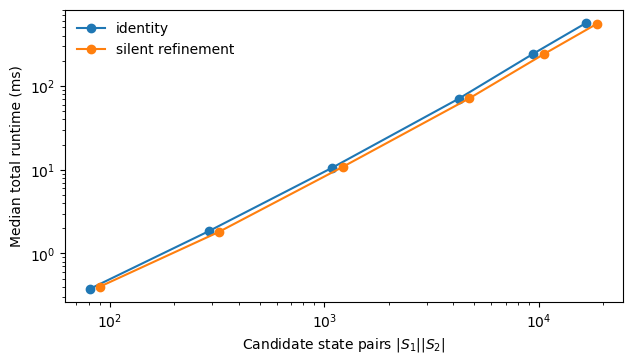

In [10]:
scaling = pd.DataFrame(mb.scalability_benchmark(
    sizes=(8, 16, 32, 64, 96, 128), repeats=3, seed=23
))
display(scaling[[
    "n_steps", "variant", "n_states_reference", "n_states_candidate",
    "candidate_relation_pairs", "total_runtime_ms", "formal_class"
]])

fig, ax = plt.subplots(figsize=(7.2, 3.8))
for variant, group in scaling.groupby("variant", sort=False):
    ax.plot(group["candidate_relation_pairs"], group["total_runtime_ms"],
            marker="o", label=variant)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Candidate state pairs $|S_1||S_2|$")
ax.set_ylabel("Median total runtime (ms)")
ax.legend(frameon=False)
plt.show()

### Independent quantifier and direction audit

`left_simulated_by_right` means that the right system matches the left.
The oracle in `src/formal_audit.py` builds weak targets from raw edges
independently of production helpers. Exact trace equality uses complete path
enumeration for the acyclic example and a finite subset-product algorithm
without a depth cutoff in general. This verifies mathematics/software, not
biological truth. To write the corresponding result reports, run
`python -m src.formal_audit` from the repository root.


In [11]:
sys.path.insert(0, str(PROJECT_ROOT))
from src import formal_audit as formal_audit

example1 = formal_audit.example1_audit()
assert example1["exact_trace_equal"]
assert example1["early_simulated_by_late"]
assert not example1["late_simulated_by_early"]
assert not example1["weak_bisimilar"]
assert example1["direct_witness_check"]["valid"]
assert example1["independent_oracle_agrees"]
display(example1)

hierarchy_audit = [formal_audit.pair_audit(*pair) for pair in formal_audit.hierarchy_pairs()]
assert all(row["independent_oracle_agrees"] for row in hierarchy_audit)
display(pd.DataFrame(hierarchy_audit).drop(columns=["independent"]))
biological_audit = [formal_audit.pair_audit(*pair) for pair in formal_audit.biological_pairs()]
assert all(row["independent_oracle_agrees"] for row in biological_audit)
display(pd.DataFrame(biological_audit)[[
    "case", "left_simulated_by_right", "right_simulated_by_left",
    "weak_bisimilar", "exact_trace_equal", "independent_oracle_agrees"
]])
exhaustive_audit = formal_audit.exhaustive_audit()
assert exhaustive_audit["all_checks_pass"]
display(exhaustive_audit)

{'case': 'Example 1 (left=late; right=early)',
 'left': 'late-choice',
 'right': 'early-choice',
 'direction_convention': 'left_simulated_by_right means left <=_w right; right matches left',
 'strong_bisimilar': False,
 'weak_bisimilar': False,
 'left_simulated_by_right': False,
 'right_simulated_by_left': True,
 'independent': {'strong_bisimilar': False,
  'weak_bisimilar': False,
  'left_simulated_by_right': False,
  'right_simulated_by_left': True},
 'independent_oracle_agrees': True,
 'exact_trace_equal': True,
 'left_trace_included_in_right': True,
 'right_trace_included_in_left': True,
 'left_only_trace': None,
 'right_only_trace': None,
 'subset_product_states': 5,
 'early_simulated_by_late': True,
 'late_simulated_by_early': False,
 'late_state_names': ['r0', 'r1', 'rb', 'rc'],
 'early_state_names': ['q0', 'qb', 'qc', 'qbt', 'qct'],
 'exact_late_language': [[], ['a'], ['a', 'b'], ['a', 'c']],
 'exact_early_language': [[], ['a'], ['a', 'b'], ['a', 'c']],
 'candidate_witness_earl

,case,left,right,direction_convention,strong_bisimilar,weak_bisimilar,left_simulated_by_right,right_simulated_by_left,independent_oracle_agrees,exact_trace_equal,left_trace_included_in_right,right_trace_included_in_left,left_only_trace,right_only_trace,subset_product_states
0,weak_not_strong,a.0,a.tau.0,left_simulated_by_right means left <=_w right; right matches left,False,True,True,True,True,True,True,True,None,None,3
1,mutual_not_bisimilar,a.(b+c)+a.b,late-choice,left_simulated_by_right means left <=_w right; right matches left,False,False,True,True,True,True,True,True,None,None,5
2,traces_not_mutual,late-choice,early-choice,left_simulated_by_right means left <=_w right; right matches left,False,False,False,True,True,True,True,True,None,None,5


,case,left_simulated_by_right,right_simulated_by_left,weak_bisimilar,exact_trace_equal,independent_oracle_agrees
0,GIM_A,True,True,True,True,True
1,GIM_B,True,True,True,True,True
2,GIM_C,False,False,False,False,True
3,GIM,True,True,True,True,True
4,DCE,True,True,True,True,True
5,SPS,True,True,True,True,True
6,RCD,False,True,False,False,True
7,AID,False,False,False,False,True
8,HPN_asynchronous_mTORi_BT20_BT549,False,True,False,False,True
9,HPN_asynchronous_mTORi_BT20_MCF7,False,False,False,False,True


{'number_of_lts': 260,
 'ordered_lts_pairs': 67600,
 'alphabet': ['a', 'tau'],
 'initial_state': 0,
 'weak_bisimilar_pairs': 41080,
 'disagreements_or_hierarchy_failures': [],
 'simulation_reflexive': True,
 'simulation_transitive': True,
 'all_checks_pass': True,
 'search_counts': {'mutual_without_bisimulation': 4848,
  'one_way_with_equal_traces': 0,
  'equal_traces_without_bisimulation': 4848},
 'first_witnesses': {'mutual_without_bisimulation': {'left': 'exhaustive-1-1',
   'right': 'exhaustive-2-3',
   'left_edges': [(0, 'a', 0)],
   'right_edges': [(0, 'a', 0), (0, 'a', 1)]},
  'equal_traces_without_bisimulation': {'left': 'exhaustive-1-1',
   'right': 'exhaustive-2-3',
   'left_edges': [(0, 'a', 0)],
   'right_edges': [(0, 'a', 0), (0, 'a', 1)]}},
 'scope': 'All edge subsets on named one/two-state systems; not all finite systems'}

## Curated model provenance

The GIM component table and transition-level references document the encoded
assumptions. Coverage is checked for all five supporting modules. Complete
provenance establishes traceability of model construction, not agreement with
independent experimental observations.


In [14]:
prov = pd.DataFrame(cbm.MODEL_PROVENANCE["GIM"],
                    columns=["Transition(s)", "Biological event", "Evidence"])
display(prov)

prov_all = pd.DataFrame(
    [(m, tr, ev, ref) for m in cbm.MODULES for tr, ev, ref in cbm.MODEL_PROVENANCE[m]],
    columns=["Module", "Transition(s)", "Biological event", "Evidence"],
)
display(prov_all)

coverage = pd.DataFrame([cbm.provenance_coverage(m) for m in cbm.MODULES])
display(coverage[["module", "n_transitions", "n_provenance_rows", "n_uncovered", "uncovered", "complete"]])
assert coverage["complete"].all(), coverage[["module", "uncovered"]].to_string(index=False)
print("OK: every Petri-net transition is named in the module provenance table.")


,Transition(s),Biological event,Evidence
0,sense_DSB,ATM-associated double-strand-break signalling,"JacksonBartek2009, BlackfordJackson2017, Yoshiyama2013"
1,sense_SSB,ATR-associated ssDNA/replication-stress signalling,"BlackfordJackson2017, Yoshiyama2013"
2,ATM_CHK2 / ATR_CHK1 / ATM_sig / ATR_sig / SOG1_program,animal checkpoint relays and the plant-specific SOG1 programme,"BlackfordJackson2017, Adachi2011, Ogita2018"
3,CHK_p53 / p53_p21_arrest / WEE1_arrest,cell-cycle arrest (p53-p21-CDK / SOG1-WEE1),"JacksonBartek2009, DeSchutter2007, Ogita2018"
4,repair_HR_NHEJ / repair_BER_NER,broad DSB and excision-repair families,"JacksonBartek2009, ManovaGruszka2015"
5,repair_ok / repair_fail,encoded recovery or unresolved-damage branch,"JacksonBartek2009, Yoshiyama2013"
6,apoptosis (animal),encoded apoptotic loss from the proliferative pool,JacksonBartek2009
7,SMR_induction + differentiation (plant),SMR-associated arrest and a combined differentiation/endoreduplica...,"Yi2014, Adachi2011, FulcherSablowski2009"


,Module,Transition(s),Biological event,Evidence
0,GIM,sense_DSB,ATM-associated double-strand-break signalling,"JacksonBartek2009, BlackfordJackson2017, Yoshiyama2013"
1,GIM,sense_SSB,ATR-associated ssDNA/replication-stress signalling,"BlackfordJackson2017, Yoshiyama2013"
2,GIM,ATM_CHK2 / ATR_CHK1 / ATM_sig / ATR_sig / SOG1_program,animal checkpoint relays and the plant-specific SOG1 programme,"BlackfordJackson2017, Adachi2011, Ogita2018"
3,GIM,CHK_p53 / p53_p21_arrest / WEE1_arrest,cell-cycle arrest (p53-p21-CDK / SOG1-WEE1),"JacksonBartek2009, DeSchutter2007, Ogita2018"
4,GIM,repair_HR_NHEJ / repair_BER_NER,broad DSB and excision-repair families,"JacksonBartek2009, ManovaGruszka2015"
5,GIM,repair_ok / repair_fail,encoded recovery or unresolved-damage branch,"JacksonBartek2009, Yoshiyama2013"
6,GIM,apoptosis (animal),encoded apoptotic loss from the proliferative pool,JacksonBartek2009
7,GIM,SMR_induction + differentiation (plant),SMR-associated arrest and a combined differentiation/endoreduplica...,"Yi2014, Adachi2011, FulcherSablowski2009"
8,DCE,glucose_uptake / glycolysis,conserved glycolysis,CB2023
9,DCE,respiration / oxphos,TCA cycle and oxidative phosphorylation,CB2023


,module,n_transitions,n_provenance_rows,n_uncovered,uncovered,complete
0,GIM,17,8,0,[],True
1,DCE,7,4,0,[],True
2,SPS,7,4,0,[],True
3,RCD,7,5,0,[],True
4,AID,6,3,0,[],True


OK: every Petri-net transition is named in the module provenance table.


## Curated observational interfaces

The interface contains the observable event labels shared by each encoded
plant--animal pair; other events are internal (`tau`). The labels are curated
functional abstractions motivated by the cited literature, not experimentally
calibrated equivalences. This table records the encoded alphabets. GIM uses
Interface A here; the three-interface experiment above separately resolves
pathways and terminal mechanisms.


In [15]:
rows = []
for m, spec in cbm.MODULES.items():
    obs_a = spec["animal"]().reachability_lts().observables
    obs_p = spec["plant"]().reachability_lts().observables
    rows.append({"module": m,
                 "common interface (\u2229)": sorted(obs_a & obs_p),
                 "animal only": sorted(obs_a - obs_p),
                 "plant only": sorted(obs_p - obs_a)})
pd.DataFrame(rows)

,module,common interface (∩),animal only,plant only
0,GIM,"[checkpoint, damage, exit_cycle, repair, restored]",[],[]
1,DCE,"[atp, branch_resp, glycolysis, reprogram, uptake]",[],[]
2,SPS,"[division, g1s, g2m, licensing, mitogen, sphase]",[],[]
3,RCD,"[autophagy, mtor_off, pcd_commit, stress, survive]",[apoptosis],[]
4,AID,"[effector, innate_signal, recognition]","[clonal_selection, memory]",[cell_wall]


## Detailed GIM Petri-net encodings

Places represent molecular states/resources, transitions represent regulatory
events (observable or internal), and tokens represent activation. The worked
example is GIM at Interface A. The plant encoding represents its terminal
response by a differentiation event preceded by internal SMR induction; this
is a model assumption, not a claim that plant differentiation is mammalian
apoptosis. Both nets are checked for safety (1-boundedness).


GIM animal: 12 places, 11 transitions, safe = True
GIM plant : 13 places, 12 transitions, safe = True


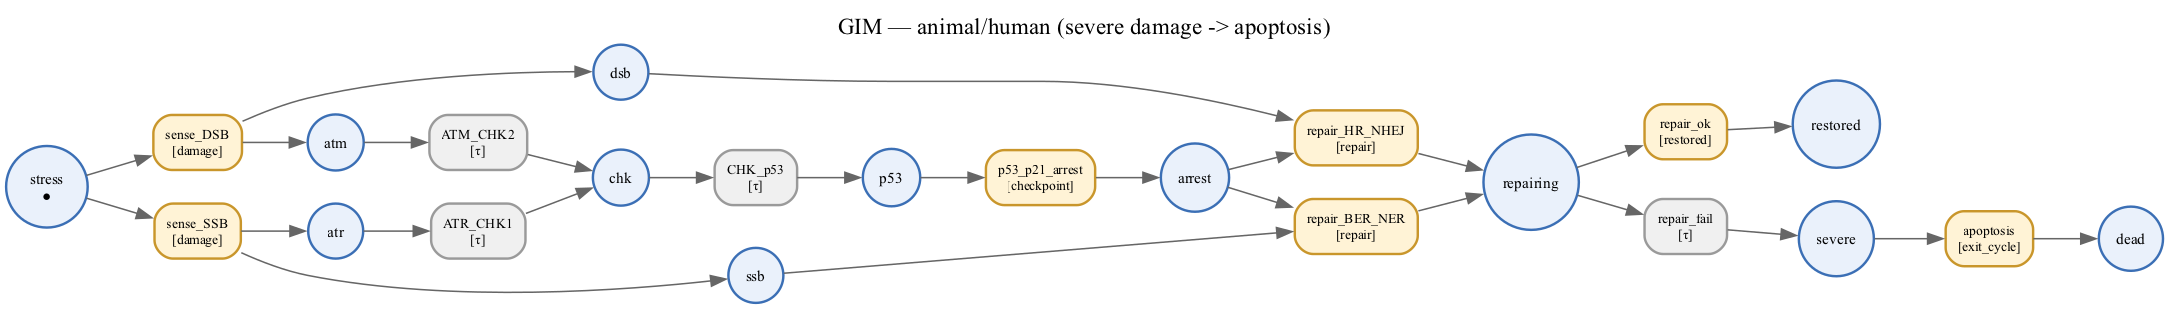

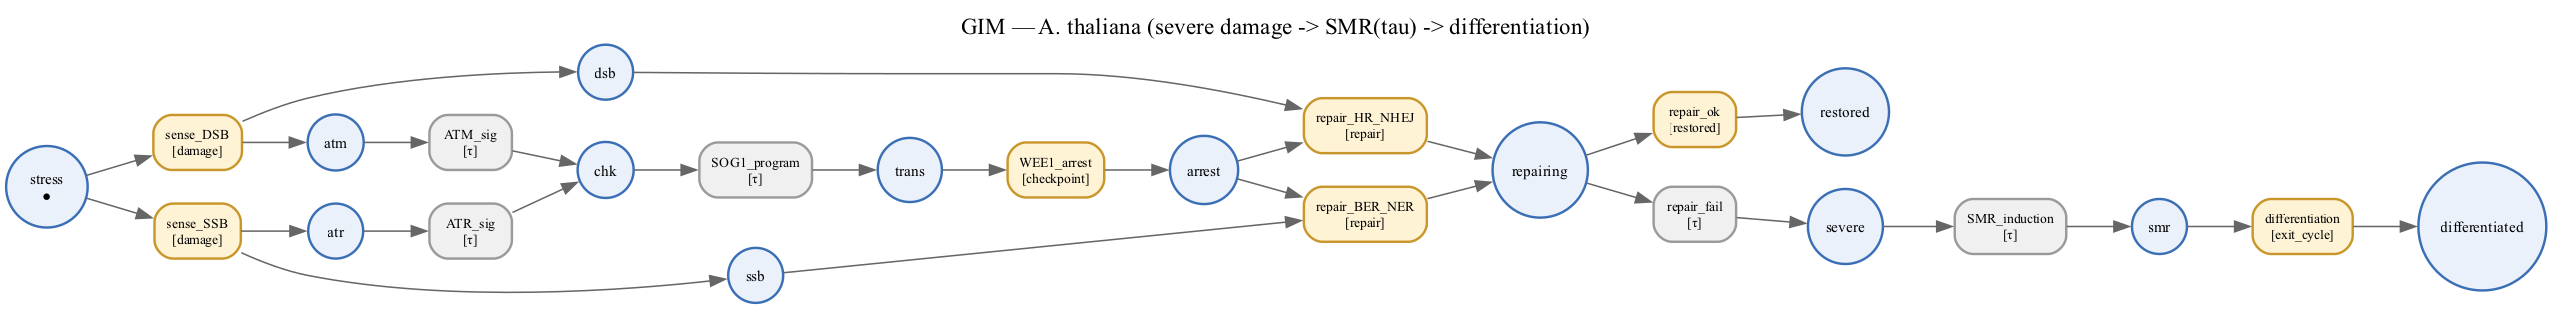

In [16]:
net_h = cbm.ddr_animal()
net_a = cbm.ddr_plant()
print("GIM animal:", len(net_h.places), "places,", len(net_h.transitions),
      "transitions, safe =", net_h.is_safe())
print("GIM plant :", len(net_a.places), "places,", len(net_a.transitions),
      "transitions, safe =", net_a.is_safe())
show_petri(net_h, "GIM — animal/human (severe damage -> apoptosis)")
show_petri(net_a, "GIM — A. thaliana (severe damage -> SMR(tau) -> differentiation)")

## GIM reachable-state comparison at Interface A

We construct each net's reachability graph (LTS), then compare strong and weak
bisimulation, both weak-simulation directions, and the Jaccard distance between
finite-depth weak observable trace sets. Weak relations abstract internal
events. A zero truncated distance alone is not proof of exact trace equality
or bisimulation.


animal LTS: 13 states, 13 edges
plant  LTS: 14 states, 14 edges


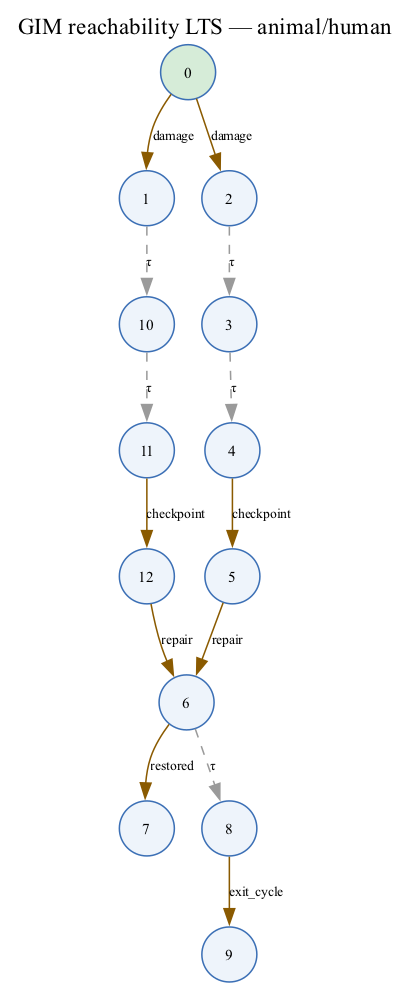

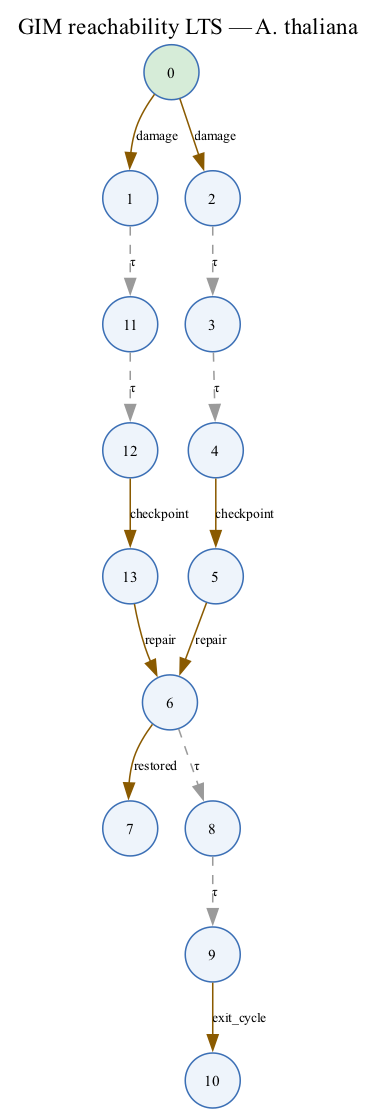

In [17]:
lts_h = net_h.reachability_lts()
lts_a = net_a.reachability_lts()
print(f"animal LTS: {len(lts_h.states)} states, {len(lts_h.edges)} edges")
print(f"plant  LTS: {len(lts_a.states)} states, {len(lts_a.edges)} edges")
show_lts(lts_h, "GIM reachability LTS — animal/human")
show_lts(lts_a, "GIM reachability LTS — A. thaliana")

In [18]:
print("== GIM module ==")
print("strong bisimulation :", cbm.strong_bisimilar(lts_h, lts_a))
print("weak bisimulation   :", cbm.weak_bisimilar(lts_h, lts_a))
print("plant  <= animal    :", cbm.weak_simulates(lts_a, lts_h))
print("animal <= plant     :", cbm.weak_simulates(lts_h, lts_a))
print("behavioural distance:", round(cbm.behavioural_distance(lts_h, lts_a), 3))
print()
print("-> NOT strongly bisimilar (internal SMR/tau events differ) but WEAKLY")
print("   bisimilar: the same observable behaviour through the interface.")

== GIM module ==
strong bisimulation : False
weak bisimulation   : True
plant  <= animal    : True
animal <= plant     : True
behavioural distance: 0.0

-> NOT strongly bisimilar (internal SMR/tau events differ) but WEAKLY
   bisimilar: the same observable behaviour through the interface.


### Reflexivity and observable-label controls

The checks verify self-bisimilarity and zero self-distance. Renaming the
reachable `checkpoint` observable in this plant encoding is a negative
weak-bisimilarity control. These are software/interface checks, not tests of
biological validity.


In [19]:
# 1) Reflexivity
assert cbm.weak_bisimilar(lts_h, lts_h)
assert cbm.behavioural_distance(lts_h, lts_h) == 0.0
# 2) Strong => weak (on the same system)
assert cbm.strong_bisimilar(lts_h, lts_h) and cbm.weak_bisimilar(lts_h, lts_h)
# 3) Falsifiability: rename the 'checkpoint' observable in the plant
broken = cbm.PetriNet(
    "GIM_plant_broken",
    [cbm.Transition(t.name, dict(t.pre), dict(t.post),
                    ("checkpoint_BROKEN" if t.label == "checkpoint" else t.label))
     for t in cbm.ddr_plant().transitions],
    dict(cbm.ddr_plant().init))
lts_broken = broken.reachability_lts()
assert not cbm.weak_bisimilar(lts_h, lts_broken)
print("OK: reflexivity, strong=>weak, and interface falsifiability all hold.")
print("Broken interface -> distance =",
      round(cbm.behavioural_distance(lts_h, lts_broken), 3),
      "| weak bisimilar =", cbm.weak_bisimilar(lts_h, lts_broken))

OK: reflexivity, strong=>weak, and interface falsifiability all hold.
Broken interface -> distance = 0.8 | weak bisimilar = False


## Supporting curated module results

The five pairs are GIM (DNA repair), DCE (energy metabolism), SPS (cell-cycle
control), RCD (death/autophagy), and AID (immune control). The classifier
distinguishes weak bisimilarity, one-way simulation with its direction, and
non-comparability. The classes and depth-six distances reproduce the accepted
paper's supporting curated comparison; GIM is evaluated at Interface A.


In [20]:
res = cbm.run_full_analysis(k=6)
tab = pd.DataFrame([c.__dict__ for c in res])[
    ["module", "strong_bisimilar", "weak_bisimilar",
     "plant_simulated_by_animal", "animal_simulated_by_plant",
     "distance", "verdict"]]
tab.columns = ["Module", "Strong bisim.", "Weak bisim.",
               "Plant<=Animal", "Animal<=Plant", "Distance", "Verdict"]
display(tab)

,Module,Strong bisim.,Weak bisim.,Plant<=Animal,Animal<=Plant,Distance,Verdict
0,GIM,False,True,True,True,0.000000,Comparable (weak bisimulation)
1,DCE,False,True,True,True,0.000000,Comparable (weak bisimulation)
2,SPS,False,True,True,True,0.000000,Comparable (weak bisimulation)
3,RCD,False,False,True,False,0.142857,Partial: sub-mechanism simulated (plant ⊑ animal)
4,AID,False,False,False,False,0.428571,Not comparable


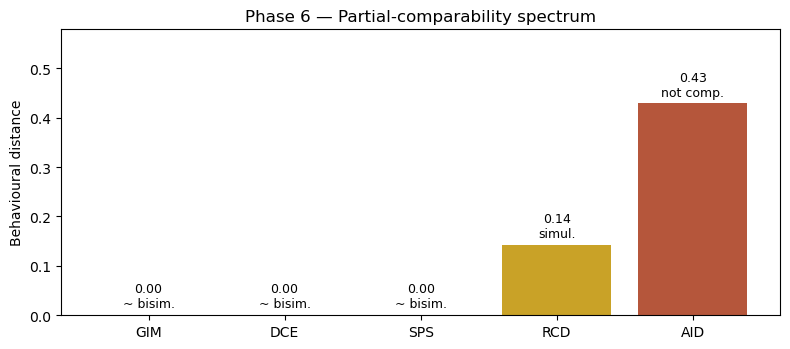

In [21]:
colors = []
for c in res:
    if c.weak_bisimilar: colors.append("#4a9b5e")
    elif c.plant_simulated_by_animal or c.animal_simulated_by_plant: colors.append("#c9a227")
    else: colors.append("#b5563b")
fig, ax = plt.subplots(figsize=(8, 3.6))
mods = [c.module for c in res]; dist = [c.distance for c in res]
ax.bar(mods, dist, color=colors)
for i, c in enumerate(res):
    tag = ("~ bisim." if c.weak_bisimilar else
           ("simul." if (c.plant_simulated_by_animal or c.animal_simulated_by_plant)
            else "not comp."))
    ax.text(i, c.distance + 0.01, f"{c.distance:.2f}\n{tag}", ha="center",
            va="bottom", fontsize=9)
ax.set_ylabel("Behavioural distance"); ax.set_ylim(0, max(dist) + 0.15)
ax.set_title("Phase 6 — Partial-comparability spectrum")
plt.tight_layout(); plt.show()

## Silent-refinement control

The implementation inserts silent steps without changing the observable
choices of these models. We test 300 refinements per module for preservation
of weak bisimilarity and the reported class. This checks the declared
abstraction of internal steps, not the biological adequacy of that abstraction.


In [22]:
rob = pd.DataFrame([cbm.robustness_under_tau_refinement(m, n=300, n_ins=4, seed=7)
                    for m in cbm.MODULES])
display(rob[["module", "base_verdict", "frac_bisim_preserved",
             "frac_verdict_preserved", "n"]])
print("All modules preserve the verdict under silent refinement:",
      bool((rob["frac_verdict_preserved"] == 1.0).all()))

,module,base_verdict,frac_bisim_preserved,frac_verdict_preserved,n
0,GIM,Comparable (weak bisimulation),1.0,1.0,300
1,DCE,Comparable (weak bisimulation),1.0,1.0,300
2,SPS,Comparable (weak bisimulation),1.0,1.0,300
3,RCD,Partial: sub-mechanism simulated (plant ⊑ animal),1.0,1.0,300
4,AID,Not comparable,1.0,1.0,300


All modules preserve the verdict under silent refinement: True


## Label-permutation null control

Each plant observable edge is relabeled with probability 0.6 using the same
alphabet while preserving the control-flow skeleton. The 2,000 permutations
per module provide an internal interface-sensitivity reference. Empirical
p-values and Benjamini-Hochberg q-values summarize these five model controls;
they are not evidence of external biological significance. The three
weakly-bisimilar modules and directional RCD case are compared with the
non-comparable AID control.


,module,observed_distance,null_mean,null_sd,p_value,q_value_bh
0,GIM,0.000000,0.767636,0.177401,0.005997,0.029985
1,DCE,0.000000,0.773578,0.223271,0.021989,0.036648
2,SPS,0.000000,0.820020,0.165595,0.013493,0.033733
3,RCD,0.142857,0.789123,0.192527,0.031984,0.039980
4,AID,0.428571,0.750438,0.174316,0.153923,0.153923


OK: conserved modules survive BH-FDR correction; AID remains non-significant.


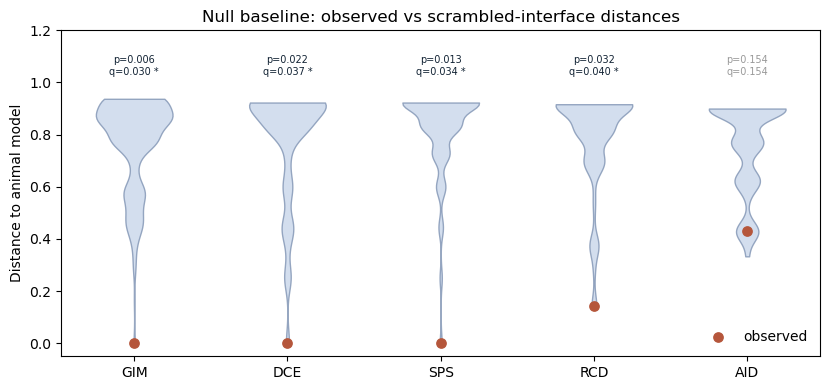

In [23]:
nb = cbm.null_baseline_suite(cbm.MODULES, n=2000, frac=0.6, seed=7)
nb_tab = pd.DataFrame([{k: v for k, v in r.items() if k != "null"} for r in nb])
display(nb_tab)

conserved = nb_tab[nb_tab["module"] != "AID"]
control_q = float(nb_tab.loc[nb_tab["module"] == "AID", "q_value_bh"].iloc[0])
assert (conserved["q_value_bh"] < 0.05).all()
assert control_q >= 0.05
print("OK: conserved modules survive BH-FDR correction; AID remains non-significant.")

fig, ax = plt.subplots(figsize=(8.4, 4))
parts = ax.violinplot([r["null"] for r in nb], showextrema=False)
for pc in parts["bodies"]:
    pc.set_facecolor("#c9d6ea"); pc.set_edgecolor("#7f93b3"); pc.set_alpha(0.8)
xs = np.arange(1, len(nb) + 1)
ax.scatter(xs, [r["observed_distance"] for r in nb], color="#b5563b", s=45,
           zorder=5, label="observed")
for i, r in enumerate(nb):
    star = " *" if r["q_value_bh"] < 0.05 else ""
    ax.text(xs[i], 1.03, f"p={r['p_value']:.3f}\nq={r['q_value_bh']:.3f}{star}",
            ha="center", fontsize=7,
            color=("#123" if r["q_value_bh"] < 0.05 else "#999"))
ax.set_xticks(xs); ax.set_xticklabels(list(cbm.MODULES)); ax.set_ylim(-0.05, 1.2)
ax.set_ylabel("Distance to animal model")
ax.set_title("Null baseline: observed vs scrambled-interface distances")
ax.legend(frameon=False, loc="lower right"); plt.tight_layout(); plt.show()


## Targeted observable-label sensitivity

Each plant observable label is renamed separately while the control-flow
skeleton is held fixed. In the weakly bisimilar curated pairs, the checks test
whether each shared label contributes to the relation: the targeted change
must break weak bisimilarity and increase the trace distance for these models.


In [24]:
iface_rows = []
for m in cbm.MODULES:
    iface_rows.extend(cbm.interface_necessity(m, k=6))
iface = pd.DataFrame(iface_rows)
display(iface[["module", "label", "base_distance", "perturbed_distance",
               "delta_distance", "verdict_changed", "weak_bisimilar_after"]])

weak_modules = {c.module for c in res if c.weak_bisimilar}
weak_iface = iface[iface["module"].isin(weak_modules)]
assert (weak_iface["delta_distance"] > 0).all()
assert (~weak_iface["weak_bisimilar_after"]).all()
print("OK: every observable label in weakly bisimilar modules is consequential.")

summary_iface = (iface.groupby("module")
                 .agg(min_delta=("delta_distance", "min"),
                      max_delta=("delta_distance", "max"),
                      changed=("verdict_changed", "sum"),
                      labels=("label", "count"))
                 .reset_index())
display(summary_iface)


,module,label,base_distance,perturbed_distance,delta_distance,verdict_changed,weak_bisimilar_after
0,GIM,checkpoint,0.000000,0.800000,0.800000,True,False
1,GIM,damage,0.000000,0.909091,0.909091,True,False
2,GIM,exit_cycle,0.000000,0.285714,0.285714,True,False
3,GIM,repair,0.000000,0.666667,0.666667,True,False
4,GIM,restored,0.000000,0.285714,0.285714,True,False
5,DCE,atp,0.000000,0.444444,0.444444,True,False
6,DCE,branch_resp,0.000000,0.444444,0.444444,True,False
7,DCE,glycolysis,0.000000,0.833333,0.833333,True,False
8,DCE,reprogram,0.000000,0.444444,0.444444,True,False
9,DCE,uptake,0.000000,0.923077,0.923077,True,False


OK: every observable label in weakly bisimilar modules is consequential.


,module,min_delta,max_delta,changed,labels
0,AID,0.000000,0.471429,0,4
1,DCE,0.444444,0.923077,5,5
2,GIM,0.285714,0.909091,5,5
3,RCD,0.232143,0.773810,5,5
4,SPS,0.250000,0.923077,6,6


## Seed sensitivity of the null control

The 2,000-permutation suite is repeated over five seeds with Benjamini-Hochberg
correction each time. GIM, DCE, and SPS remain below 0.05; RCD may be
borderline. These diagnostics do not determine the formal relation classes:
RCD's partial correspondence follows from one-way simulation, independently
of its permutation p-value.


In [25]:
seed_sens = pd.DataFrame(cbm.null_seed_sensitivity(cbm.MODULES, n=2000, frac=0.6))
display(seed_sens)

stable = seed_sens[seed_sens["module"].isin(["GIM", "DCE", "SPS"])]
assert stable["all_q_lt_0_05"].all()
assert not bool(seed_sens.loc[seed_sens["module"] == "AID", "all_q_lt_0_05"].iloc[0])
print("OK: GIM/DCE/SPS are stable across seeds; AID remains non-significant.")
print("RCD q range:", seed_sens.loc[seed_sens["module"] == "RCD", ["q_min", "q_max"]].to_dict("records")[0])


,module,seeds,n_per_seed,q_min,q_median,q_max,p_min,p_median,p_max,all_q_lt_0_05
0,GIM,"1,7,13,29,101",2000,0.017491,0.029985,0.032484,0.003498,0.005997,0.007496,True
1,DCE,"1,7,13,29,101",2000,0.031651,0.034150,0.036648,0.014993,0.020490,0.021989,True
2,SPS,"1,7,13,29,101",2000,0.031651,0.033733,0.034983,0.012994,0.013993,0.019490,True
3,RCD,"1,7,13,29,101",2000,0.039980,0.048726,0.054973,0.031984,0.038981,0.043978,False
4,AID,"1,7,13,29,101",2000,0.153923,0.160420,0.166417,0.153923,0.160420,0.166417,False


OK: GIM/DCE/SPS are stable across seeds; AID remains non-significant.
RCD q range: {'q_min': 0.039980009995002494, 'q_max': 0.054972513743128434}


## Trace-depth sensitivity

The distance uses traces truncated at depth `k`. For these acyclic modules,
the observable languages are finite; the distance is exact once `k` covers
the longest observable path. The plotted curves document stability around
the reported depth six. This finite-depth diagnostic does not replace the
independent exact-language checks used for the formal witnesses.


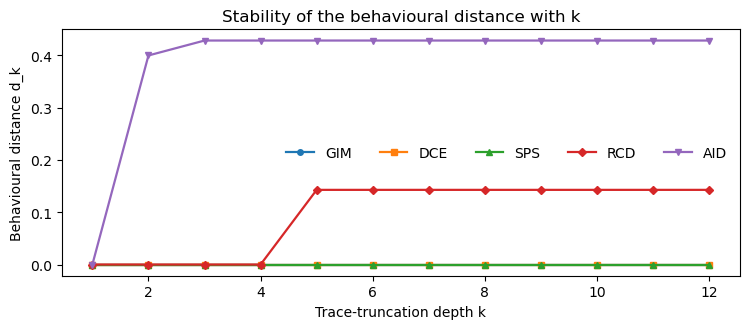

In [26]:
fig, ax = plt.subplots(figsize=(7.6, 3.4))
markers = {"GIM": "o", "DCE": "s", "SPS": "^", "RCD": "D", "AID": "v"}
for m in cbm.MODULES:
    curve = cbm.distance_curve(m, kmax=12)
    ax.plot([k for k, _ in curve], [d for _, d in curve],
            marker=markers[m], label=m, linewidth=1.6, markersize=4)
ax.set_xlabel("Trace-truncation depth k"); ax.set_ylabel("Behavioural distance d_k")
ax.set_title("Stability of the behavioural distance with k")
ax.legend(frameon=False, ncol=5); plt.tight_layout(); plt.show()

## RCD observable-interface control

The accepted paper's directional RCD result is conditional on the observable
interface: the animal encoding exposes apoptosis, whereas the plant
metacaspase event is internal. The following diagnostic changes only that
plant event's label to `apoptosis`. It tests the role of the label in these two
encoded nets, not a biological intervention or an equivalence between plant
and animal cell death. The printed single-factor conclusion is limited to
this model/interface manipulation.


In [27]:
patched = cbm.PetriNet(
    "RCD_plant_patched",
    [cbm.Transition(t.name, dict(t.pre), dict(t.post),
                    ("apoptosis" if t.name == "metacaspase_exec" else t.label))
     for t in cbm.death_plant().transitions],
    dict(cbm.death_plant().init))
lts_rcd_h = cbm.death_animal().reachability_lts()
print("RCD original  — weak bisimilar:",
      cbm.weak_bisimilar(lts_rcd_h, cbm.death_plant().reachability_lts()))
print("RCD patched   — weak bisimilar:",
      cbm.weak_bisimilar(lts_rcd_h, patched.reachability_lts()))
print("\n-> Confirms the single factor breaking RCD comparability is the")
print("   canonical apoptotic-execution observable, absent in the plant.")

RCD original  — weak bisimilar: False
RCD patched   — weak bisimilar: True

-> Confirms the single factor breaking RCD comparability is the
   canonical apoptotic-execution observable, absent in the plant.


## Summary

- Death-receptor variants share stable fates under sustained TNF, but global
  sustained trace equality is refuted by a verified 12-action counterexample.
  Reverse sustained inclusion remains undecided. Global withdrawal trace
  inclusions fail in both directions. Selected shared-state continuations
  agree under sustained input and have one-way simulation after withdrawal.
- GIM holds structure fixed: PN-GDDA is 0.9976 at all three interfaces.
  Interfaces A/B are weakly bisimilar with depth-six distance zero; neither
  simulation direction holds at C, whose distance is 0.352941.
- The five curated controls retain three weakly bisimilar pairs, directional
  plant-in-animal RCD simulation, and non-comparable AID. Provenance, silent
  refinements, and label/depth/seed diagnostics check encoded assumptions.
- Example 1 has early-to-late simulation but not its reverse despite exact
  trace equality. All three hierarchy witnesses and the 32 audited model
  pairs agree with the independent raw-edge computations. Exhaustive checks
  agree on 67,600 ordered pairs of 260 one-/two-state LTSs over `{a, tau}`.
- Six constructed cases recover all predeclared formal classes. On the binary
  weak-equivalence task, weak bisimulation scores 6/6, truncated traces 5/6,
  LTS-GDA 4/6, the structural profile 3/6, and PN-GDDA 2/6 at the fixed 0.9
  threshold; no PN-GDDA score cutoff exceeds 4/6 on this benchmark.
- The 151-graphlet/592-slot catalog matches the inspected Holmes releases;
  the independent reference score agrees to 12 decimal places. The
  576-orbit sensitivity changes no reported threshold decision.
- mCRL2 agrees on all 42 strong/weak decisions for six synthetic cases, six
  public-model controls, and nine HPN pairs. The cell-cycle and p53--Mdm2
  controls have 826 and 17 reachable asynchronous states, respectively.
- Structure-only HPN medoids yield six directional simulations and three
  non-comparable asynchronous pairs; synchronous execution preserves seven
  of nine classes. Held-out response diagnostics remain inconclusive, and
  native CASPOTS specificity is not established (`p=0.25`). No ordinal
  formal-class test is used.

These results classify explicit models under declared semantics and interfaces;
they do not establish experimental equivalence or predictive biological
validity. Stored runtime measurements are machine-dependent. The canonical
sources are `Journal/main.tex` and `Journal/supplement.tex`; execution and
independent-record regeneration instructions are at the start of this notebook.
